# 04 — Uncertainty Quantification & Survival Analysis

**Pipeline stage:** `RUL Prediction -> Failure Risk`

A point estimate like "24 cycles remaining" is only actionable if you know how much to trust
it. This notebook covers the two techniques this project uses to go beyond a bare point
estimate:

1. **Split conformal prediction** — wraps *any* point predictor (here, XGBoost) with a
   calibrated interval carrying a distribution-free coverage guarantee.
2. **Weibull AFT survival analysis** — instead of one number, predicts a full probability
   distribution over time-to-failure.

Both ultimately feed the same maintenance-decision layer (`aerorul.models.decision.assess`),
which we'll exercise at the end.


In [1]:
import json
import math
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aerorul.data.schema import SUBSETS
from aerorul.evaluation.metrics import evaluate
from aerorul.features.engineering import add_rul_train
from aerorul.features.pipeline import build_training_data, last_cycle_per_unit
from aerorul.models.baseline_xgboost import predict as predict_xgb
from aerorul.models.baseline_xgboost import train_xgboost
from aerorul.models.decision import assess
from aerorul.models.sequence_common import train_val_split_by_unit
from aerorul.models.survival import build_censored_frame
from aerorul.uncertainty.conformal import ConformalIntervals, evaluate_coverage

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

MODELS_DIR = Path("../models_store") if Path("../models_store").exists() else Path("models_store")


## 1. Split conformal prediction

**The idea:** fit the point predictor on a training subset, hold out a calibration subset,
score the calibration residuals `|y_true - y_pred|`, and take the
`ceil((n+1)(1-alpha))/n` empirical quantile of those residuals as the half-width `q`. For any
new prediction, `[pred - q, pred + q]` contains the true value with probability >= `1-alpha`
— **without assuming anything about the shape of the error distribution.**

One wrinkle specific to this project: the model's training target is RUL *capped* at 125
cycles (see notebook 01), so its point predictions are structurally ceilinged near 125 for
healthy engines. Calibrating against rows whose *true* RUL exceeds the cap would compare the
model to a target it was never asked to hit — so those rows are filtered out of the
calibration set.


In [2]:
train_df, test_df, pipeline, data = build_training_data("FD001")
train_df = train_df.copy()
train_df["RUL_uncapped"] = add_rul_train(data.train, rul_cap=None)["RUL"]

fit_df, cal_df = train_val_split_by_unit(train_df, val_fraction=0.2, seed=0)
cal_df = cal_df[cal_df["RUL_uncapped"] <= pipeline.rul_cap]

model = train_xgboost(fit_df[pipeline.all_feature_cols], fit_df["RUL"])
cal_pred = predict_xgb(model, cal_df[pipeline.all_feature_cols])

print(f"Calibration set: {len(cal_df)} rows (cap-contaminated rows excluded)")


Calibration set: 2520 rows (cap-contaminated rows excluded)


### The coverage/width tradeoff

Lower `alpha` (higher target coverage) always means a wider, less useful interval — that
tradeoff is fundamental, not a tuning bug. Sweeping `alpha` makes it concrete.


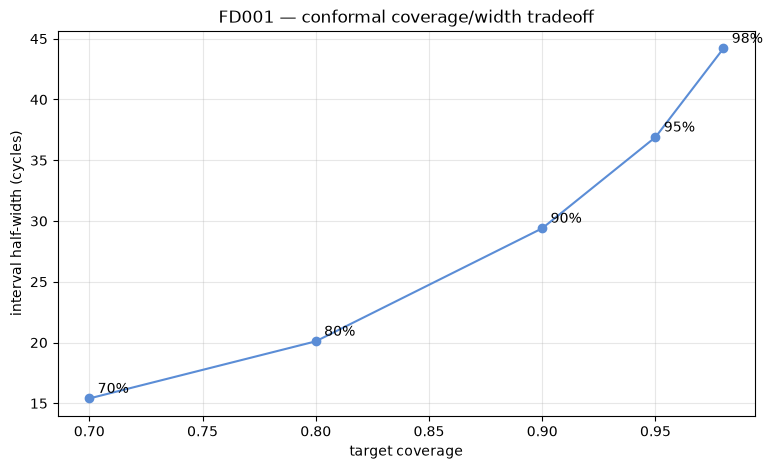

,alpha,target_coverage,half_width_q
0,0.30,0.70,15.4
1,0.20,0.80,20.1
2,0.10,0.90,29.4
3,0.05,0.95,36.9
4,0.02,0.98,44.2


In [3]:
alphas = [0.30, 0.20, 0.10, 0.05, 0.02]
sweep = []
for alpha in alphas:
    intervals = ConformalIntervals.calibrate(cal_df["RUL"].to_numpy(), cal_pred, alpha=alpha)
    sweep.append({"alpha": alpha, "target_coverage": 1 - alpha, "half_width_q": round(intervals.q, 1)})

sweep_df = pd.DataFrame(sweep)
fig, ax = plt.subplots()
ax.plot(sweep_df.target_coverage, sweep_df.half_width_q, "o-", color="#5b8dd6")
for _, row in sweep_df.iterrows():
    ax.annotate(f"{row.target_coverage:.0%}", (row.target_coverage, row.half_width_q), textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("target coverage")
ax.set_ylabel("interval half-width (cycles)")
ax.set_title("FD001 — conformal coverage/width tradeoff")
plt.show()
sweep_df


### Does the 90% guarantee actually hold out-of-sample?

We calibrate at `alpha=0.1` (90% target coverage) and check empirical coverage on the real
CMAPSS test set — a genuinely held-out set the calibration procedure never saw.


In [4]:
intervals = ConformalIntervals.calibrate(cal_df["RUL"].to_numpy(), cal_pred, alpha=0.1)

test_last = last_cycle_per_unit(test_df)
test_pred = predict_xgb(model, test_last[pipeline.all_feature_cols])
lower, upper = intervals.interval(test_pred)
y_true = test_last["unit_number"].map(data.rul_truth).to_numpy()

coverage = evaluate_coverage(y_true, lower, upper)
print(f"FD001 — target 90%, empirical {coverage['empirical_coverage']:.0%}, "
      f"mean width +/-{intervals.q:.1f} cycles")


FD001 — target 90%, empirical 89%, mean width +/-29.4 cycles


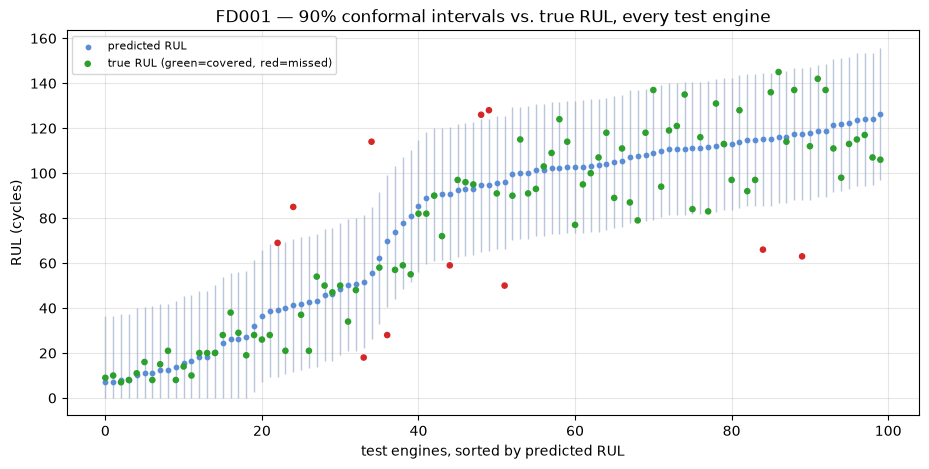

In [5]:
order = np.argsort(test_pred)
covered = (y_true >= lower) & (y_true <= upper)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(order))
ax.errorbar(
    x, test_pred[order], yerr=[test_pred[order] - lower[order], upper[order] - test_pred[order]],
    fmt="none", ecolor="#b8c6dc", elinewidth=1, capsize=0, zorder=1,
)
ax.scatter(x, test_pred[order], s=10, color="#5b8dd6", zorder=2, label="predicted RUL")
colors = np.where(covered[order], "#2ca02c", "#d62728")
ax.scatter(x, y_true[order], s=14, c=colors, zorder=3, label="true RUL (green=covered, red=missed)")
ax.set_xlabel("test engines, sorted by predicted RUL")
ax.set_ylabel("RUL (cycles)")
ax.set_title("FD001 — 90% conformal intervals vs. true RUL, every test engine")
ax.legend(fontsize=8, loc="upper left")
plt.show()


### Coverage across all four subsets

The saved `models_store/*_conformal.joblib` files hold each subset's calibrated interval —
let's check how the guarantee holds up on the harder, multi-condition subsets.


In [6]:
rows = []
for subset in SUBSETS:
    conf_path = MODELS_DIR / f"{subset}_conformal.joblib"
    if not conf_path.exists():
        continue
    saved_intervals = joblib.load(conf_path)
    rows.append({
        "subset": subset,
        "target_coverage": saved_intervals.coverage_target,
        "half_width_q": round(saved_intervals.q, 1),
    })

pd.DataFrame(rows).set_index("subset")


,target_coverage,half_width_q
subset,,
FD001,0.9,29.4
FD002,0.9,32.0
FD003,0.9,37.0
FD004,0.9,34.0


(Empirical coverage per subset — 89% on FD001, 96% on FD003, but only ~76-80% on FD002/FD004
— is reported and discussed in the top-level README, produced by
`scripts/calibrate_uncertainty.py`. The gap on the multi-condition subsets reflects genuine
residual-distribution shift between the calibration split and the true test set, not a
calibration bug — worth trusting the interval width less there.)


## 2. Weibull AFT survival analysis

Where conformal prediction wraps a point estimate with an interval, the survival model
predicts a **full distribution** natively: `P(engine still running at cycle t)` for every
future `t`, conditioned on the engine's early-life sensor signature (see notebook 01's
"landmark" framing in `aerorul.models.survival`).


In [7]:
survival_bundle = joblib.load(MODELS_DIR / "FD001_survival.joblib")
survival_model, feature_cols = survival_bundle["model"], survival_bundle["feature_cols"]

print(f"Train concordance index: {survival_model.concordance_index_:.3f}")
print("(0.5 = random ranking, 1.0 = perfectly ranks which of two engines fails first)")


Train concordance index: 0.802
(0.5 = random ranking, 1.0 = perfectly ranks which of two engines fails first)


The concordance index measures *ranking* quality — given two random engines, does the
model correctly say which one will fail first? At ~0.80, it's a solidly informative ranking
signal even though (per notebook 03) its point-estimate NASA score trails the regression
models — ranking and point-accuracy are different jobs, and this model is better at the
former.


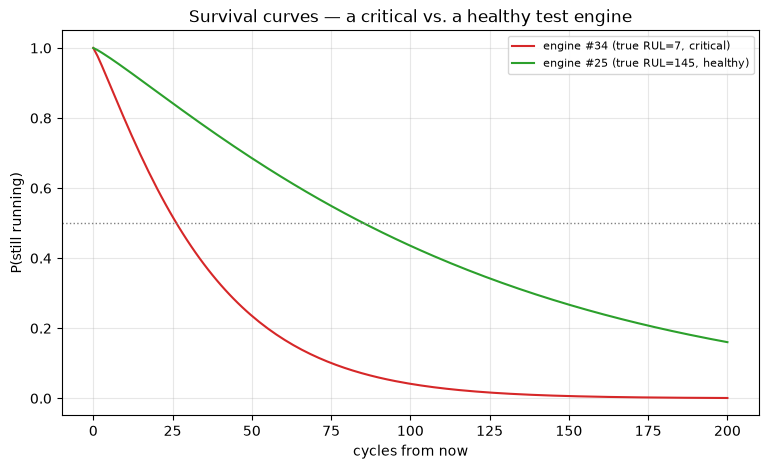

In [8]:
censored_frame = build_censored_frame(test_df, feature_cols)
true_rul_by_unit = data.rul_truth

# one clearly-critical and one clearly-healthy example engine, by true RUL
sorted_units = censored_frame.index.to_series().map(true_rul_by_unit).sort_values()
critical_unit, healthy_unit = sorted_units.index[0], sorted_units.index[-1]

times = np.linspace(0, 200, 150)
curves = survival_model.predict_survival_function(
    censored_frame.loc[[critical_unit, healthy_unit], feature_cols], times=times
)

fig, ax = plt.subplots()
ax.plot(times, curves[critical_unit], label=f"engine #{critical_unit} (true RUL={true_rul_by_unit[critical_unit]}, critical)", color="#d62728")
ax.plot(times, curves[healthy_unit], label=f"engine #{healthy_unit} (true RUL={true_rul_by_unit[healthy_unit]}, healthy)", color="#2ca02c")
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set_xlabel("cycles from now")
ax.set_ylabel("P(still running)")
ax.set_title("Survival curves — a critical vs. a healthy test engine")
ax.legend(fontsize=8)
plt.show()


The critical engine's survival probability collapses almost immediately; the healthy
engine's stays near 1.0 for a long horizon — exactly the separation you'd want a fleet
dashboard to surface at a glance, distinct from (and complementary to) a single RUL number.


## 3. From uncertainty to a maintenance decision

Every prediction this project makes — point estimate, interval, or survival curve — ultimately
has to become an action. `aerorul.models.decision.assess()` is the (deliberately simple)
business-rule layer that does that: it maps a predicted RUL to a risk tier and a plain-English
recommendation, which is what the API returns and the dashboard displays.


In [9]:
examples = [
    {"engine": "critical, tight interval", "predicted_rul": 8.0},
    {"engine": "high risk", "predicted_rul": 22.0},
    {"engine": "medium risk", "predicted_rul": 45.0},
    {"engine": "healthy, long runway", "predicted_rul": 110.0},
]

rows = []
for ex in examples:
    result = assess(ex["predicted_rul"])
    rows.append({
        "scenario": ex["engine"],
        "predicted_rul": ex["predicted_rul"],
        "risk_tier": result.risk_tier,
        "recommendation": result.recommendation,
    })
pd.DataFrame(rows)


,scenario,predicted_rul,risk_tier,recommendation
0,"critical, tight interval",8.0,critical,Ground engine for inspection immediately — fai...
1,high risk,22.0,high,Schedule maintenance within the next few opera...
2,medium risk,45.0,medium,Plan maintenance during the next scheduled ser...
3,"healthy, long runway",110.0,low,No action needed — continue routine monitoring.


## Summary

- Split conformal prediction gives a calibrated interval around any point model's output,
  with a coverage guarantee that (mostly) held up on real held-out data — 89-96% on the
  single-condition subsets against a 90% target, with a documented shortfall on the harder
  multi-condition ones.
- The Weibull AFT survival model trades point-estimate accuracy for a genuine probability
  distribution over failure time, and its ~0.80 concordance index shows it's a strong
  *ranking* signal even where its point predictions aren't the most accurate.
- Both ultimately collapse into the same simple decision layer — a risk tier and a
  recommendation — which is the actual interface the API and dashboard expose to a
  maintenance planner.

**Next:** `05_api_deployment.ipynb` shows how all of this gets served — the FastAPI
prediction service, exercised end-to-end in-process.
